In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from translator import SeamlessTranslator
from config import M4TLargeTranslatorConfig
args = M4TLargeTranslatorConfig
st = SeamlessTranslator(args)

2024-07-01 11:59:31.883684: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-01 11:59:31.883787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-01 11:59:31.891703: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-01 11:59:31.913840: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-01 11:59:35.911446: W tensorflow/compiler/tf2

In [65]:
inputs = st.processor(
    # text = "We finetune CLIP, which consists of a text Transformer and a vision Transformer pretrained to align images and captions in the WebImageText corpus.",
    # text="We fine-tune T5-Large and T5-11B; these encoder-decoder transformer models have 770M and 11.3B parameters respectively.",
    text="The zero-shot version of GPT4 is missing access not only to the supervision of paired data.",
    src_lang = st.args.lang_dict['English'],
    return_tensors="pt"
).input_ids

In [66]:
gen_outputs = st.model.generate(
    inputs.to(st.device),
    tgt_lang=st.args.lang_dict['Chinese'],
    generate_speech=False,
    output_attentions=True
)
gen_outputs.keys()

odict_keys(['sequences', 'scores', 'encoder_attentions', 'encoder_hidden_states', 'decoder_attentions', 'cross_attentions', 'decoder_hidden_states', 'past_key_values'])

In [67]:
import torch
def get_att(gen_outputs):
    # Assuming outputs.cross_attentions is the list obtained from the generate() function
    cross_attentions = gen_outputs.cross_attentions  # This is of shape [sequence_length][n_layers][batch_size, n_heads, 1 or 2, input_sequence_length]

    sequence_length = len(cross_attentions)
    n_layers = len(cross_attentions[0])
    batch_size, n_heads, _, input_sequence_length = cross_attentions[0][0].shape

    # Initialize a list to store reshaped cross-attentions
    reshaped_cross_attentions = [[] for _ in range(n_layers)]

    # Iterate over layers
    for layer in range(n_layers):
        # Collect attention matrices for the current layer across all sequence lengths
        layer_attentions = []
        for seq in range(sequence_length):
            if seq == 0:
                layer_attentions = list(torch.split(cross_attentions[seq][layer], 1, dim=2))
            else:
                layer_attentions.append(cross_attentions[seq][layer])
        
        # Stack along the new axis (decoder sequence length)
        stacked_attentions = torch.cat(layer_attentions, dim=2)  # Shape: [batch_size, n_heads, sequence_length, input_sequence_length]
        
        # Append to the reshaped list
        reshaped_cross_attentions[layer] = stacked_attentions

    # Now reshaped_cross_attentions is a list of length n_layers
    # Each element has shape [batch_size, n_heads, sequence_length, input_sequence_length]
    return reshaped_cross_attentions
att = get_att(gen_outputs)

In [68]:
encoder_text = st.processor.tokenizer.convert_ids_to_tokens(inputs[0])
decoder_text = st.processor.tokenizer.convert_ids_to_tokens(gen_outputs['sequences'][0][1:])

In [39]:
len(encoder_text), len(decoder_text)

(40, 46)

In [19]:
from matplotlib import font_manager
font_manager.fontManager.addfont('/data/user_data/jiaruil5/miniconda3/envs/new/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf')

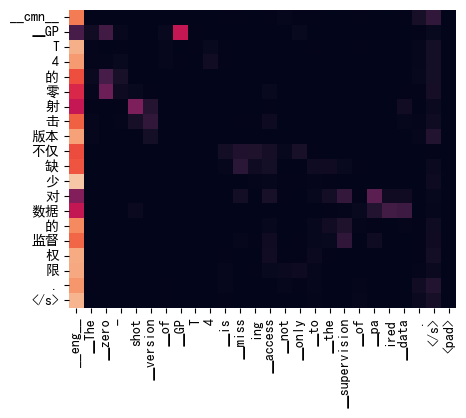

In [69]:
# https://nlp.seas.harvard.edu/2018/04/03/attention.html
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = ['SimHei']
def draw(data, x, y, ax):
    sns.heatmap(data, 
        xticklabels=x, square=True, yticklabels=y, vmin=0.0, vmax=1.0, 
        cbar=False, ax=ax)
fig, axs = plt.subplots(1, 1, figsize=(5, 10))
att = att[-2]
att = torch.mean(att, dim=1)[0]
draw(att.cpu(), encoder_text, decoder_text, axs)
# draw(reshaped_cross_attentions[-1][0, -1, :, :].cpu(), encoder_text, decoder_text, axs)

In [47]:
att.shape

torch.Size([46, 40])

In [70]:
print(encoder_text)

['__eng__', '▁The', '▁zero', '-', 'shot', '▁version', '▁of', '▁GP', 'T', '4', '▁is', '▁miss', 'ing', '▁access', '▁not', '▁only', '▁to', '▁the', '▁supervision', '▁of', '▁pa', 'ired', '▁data', '.', '</s>', '<pad>']


In [71]:
def get_top_k(att, encoder_text, decoder_text, encoder_subset, top_k=3):
    att = att.transpose(0, 1)
    res = []
    for item_i in encoder_subset:
        for idx, item_j in enumerate(encoder_text):
            if item_i == item_j:
                top_vals, top_indices = torch.topk(att[idx], k=top_k)
                vals = []
                for i in top_indices:
                    vals.append(decoder_text[i])
                res.append((item_i, vals))
                break
    return res
get_top_k(att, encoder_text, decoder_text, ['▁zero', '-', 'shot', '▁version', '▁supervision'], top_k=3)

[('▁zero', ['零', '的', '▁GP']),
 ('-', ['的', '零', '4']),
 ('shot', ['射', '击', '数据']),
 ('▁version', ['击', '射', '版本']),
 ('▁supervision', ['对', '监督', '的'])]

In [ ]:
att

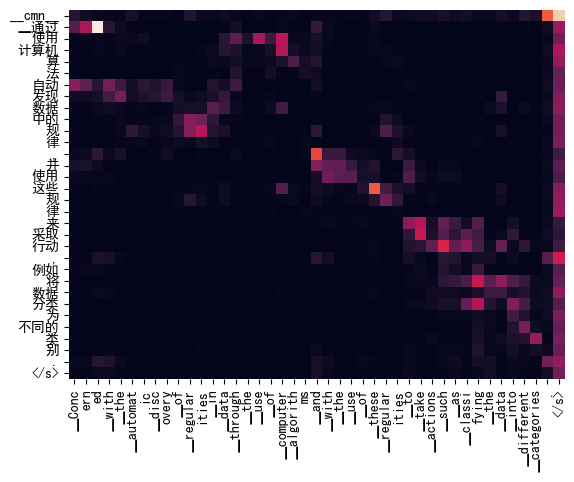

In [17]:
def draw(data, x, y, ax):
    sns.heatmap(data, 
        xticklabels=x, square=True, yticklabels=y, 
        cbar=False, ax=ax)
fig, axs = plt.subplots(1, 1)
draw(torch.mean(reshaped_cross_attentions[-1].cpu(), dim=1, keepdim=False)[0][:, 1:], encoder_text[1:], decoder_text, axs)